#  Predicting Hospital Readmissions (Healthcare Analytics)

###  Objective
Build a machine learning model to identify patients at high risk of being readmitted within 30 days.

###  Business Impact
Early prediction helps hospitals reduce costs, improve patient care, and avoid penalties.

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##  Dataset Overview

- Source: UCI Machine Learning Repository  
- Records: ~100,000 patient encounters  
- Features: Demographics, diagnoses, medications, hospital stay details  

###  Target Variable
- 1 → Readmitted within 30 days  
- 0 → Not readmitted

In [13]:
df = pd.read_csv("/content/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Handling Missing Values

In [14]:
df.replace('?', pd.NA, inplace=True)

df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [15]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),<NA>,6,25,1,1,<NA>,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),<NA>,1,1,7,3,<NA>,<NA>,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,<NA>,<NA>,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),<NA>,1,1,7,2,<NA>,<NA>,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),<NA>,1,1,7,1,<NA>,<NA>,...,No,Steady,No,No,No,No,No,Ch,Yes,0


##  Exploratory Data Analysis



###  Readmission Distribution
The dataset is highly imbalanced, with significantly fewer patients readmitted within 30 days.

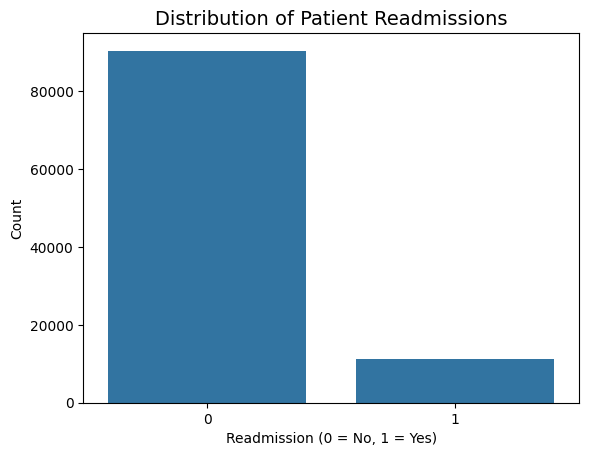

In [26]:
sns.countplot(x='readmitted', data=df)
plt.title("Distribution of Patient Readmissions", fontsize=14)
plt.xlabel("Readmission (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

###  Age vs Readmission
Certain age groups show higher readmission patterns, indicating demographic influence on risk.

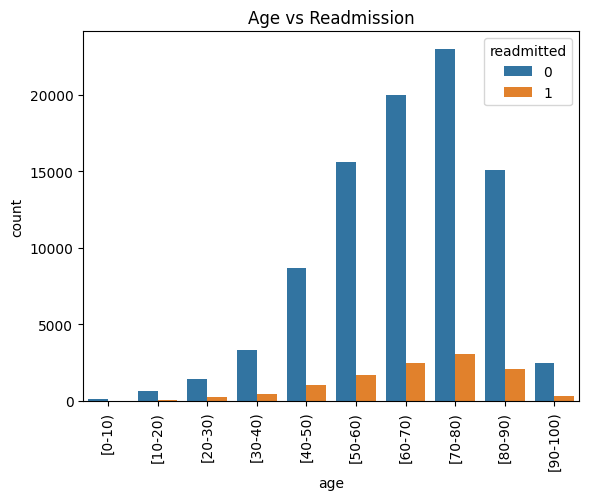

In [17]:
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=90)
plt.title("Age vs Readmission")
plt.show()

###  Hospital Stay Duration
Patients with longer hospital stays tend to have a higher probability of readmission.

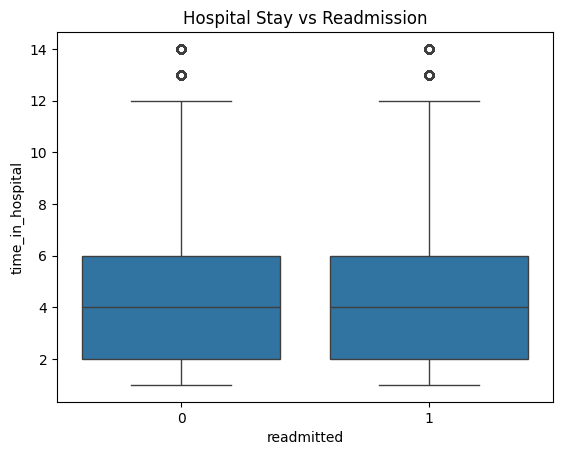

In [18]:
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title("Hospital Stay vs Readmission")
plt.show()

##  Model Development

### Approach
- Data preprocessing and encoding
- Train-test split
- Logistic Regression as baseline model


In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

##  Results & Evaluation

The model demonstrates reasonable performance in predicting readmissions.

### Key Observations
- High accuracy for non-readmitted patients  
- Lower recall for readmitted patients due to class imbalance  
- Advanced models improve prediction capability

In [21]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18146
           1       0.50      0.02      0.04      2208

    accuracy                           0.89     20354
   macro avg       0.70      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354



In [24]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

##  Conclusion

This project demonstrates how machine learning can be applied to healthcare data to predict patient readmissions.

By identifying high-risk patients early, hospitals can take preventive actions, optimize resource allocation, and improve overall patient outcomes.